# DeepLog: Anomaly Detection for OAuth2 Logs

This notebook implements **DeepLog**, an LSTM-based approach for log anomaly detection using a custom implementation.

## Methodology
DeepLog treats logs as sequences of events and uses an LSTM model to:
1. Learn patterns from normal execution sequences
2. Predict the next log event based on previous events
3. Flag significant deviations from predictions as anomalies

## Pipeline Overview
1. **Data Loading**: Load OAuth2 logs using LO2Loader
2. **Preprocessing**: Parse logs with Drain to extract event templates
3. **Sequence Creation**: Build event sequences from logs
4. **Event Encoding**: Convert events to integer IDs using DeepLog Preprocessor
5. **Model Training**: Train LSTM on normal sequences
6. **Anomaly Detection**: Detect anomalies based on top-k prediction errors

## Custom DeepLog Library
Uses custom implementation in `deepLog/` folder compatible with current packages.

## 1. Import Libraries

This notebook uses a custom DeepLog implementation located in the `deepLog/` folder.

In [1]:
import time
import numpy as np
import polars as pl
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)

In [2]:
# DeepLog library imports (custom implementation)
from deepLog import DeepLog
from deepLog.preprocessor import Preprocessor


In [3]:
# LogLead imports (similar to analysis.py)
from loglead.loaders import LO2Loader
from loglead.enhancers import EventLogEnhancer


## 2. Configuration and Data Loading

In [4]:
# Configuration
log_data = r"light-oauth2-logs"
n_runs = 100  # Number of runs to process
errors_per_run = 1  # Number of errors per run
dup_errors = True  # Allow duplicate errors

# DeepLog specific parameters
window_size = 10  # Number of previous events to consider for prediction
num_candidates = 9  # Top-k candidates for anomalyy detection
epochs = 50
batch_size = 64
hidden_size = 128
num_layers = 2
learning_rate = 0.001

print("Configuration:")
print(f"  Data path: {log_data}")
print(f"  Window size: {window_size}")
print(f"  Top-k candidates: {num_candidates}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"  LSTM hidden size: {hidden_size}")
print(f"  LSTM layers: {num_layers}")

Configuration:
  Data path: light-oauth2-logs
  Window size: 10
  Top-k candidates: 9
  Epochs: 50
  Batch size: 64
  LSTM hidden size: 128
  LSTM layers: 2


In [5]:
# Load data using LO2Loader
print("Loading data...")
stime = time.time()

loader = LO2Loader(
    filename=log_data, 
    n_runs=n_runs, 
    errors_per_run=errors_per_run, 
    dup_errors=dup_errors
)

df = loader.execute()
df = loader.reduce_dataframes(frac=0.1)
df_seq = loader.df_seq

print(f"Time loaded: {time.time() - stime:.2f}s")
print(f"Event dataframe shape: {df.shape}")
print(f"Sequence dataframe shape: {df_seq.shape}")

# Filter null messages
df = df.filter(pl.col("m_message").is_not_null())

# Check distribution
print(f"\nSequence distribution:")
print(f"  Normal sequences: {len(df_seq.filter(df_seq['normal'] == True))}")
print(f"  Anomalous sequences: {len(df_seq.filter(df_seq['normal'] == False))}")

Loading data...
Service type set: 
Time loaded: 65.37s
Event dataframe shape: (244658, 8)
Sequence dataframe shape: (139, 6)

Sequence distribution:
  Normal sequences: 75
  Anomalous sequences: 64


## 3. Log Preprocessing and Event Extraction

We'll use the Drain algorithm to parse raw log messages into event templates, which will serve as the vocabulary for DeepLog.

In [6]:
# Preprocessing with EventLogEnhancer (for Drain parsing)
print("Preprocessing logs...")
stime = time.time()

enhancer = EventLogEnhancer(df)

# Normalization: replace digits and sequences of zeros
regexs = [('0', r'\d'), ('0', '0+')]
df = enhancer.normalize(regexs, to_lower=True, twice=False)
print(f"Time normalized: {time.time() - stime:.2f}s")

# Parse logs with Drain to extract event templates
stime = time.time()
df = enhancer.parse_drain()
print(f"Time parsed: {time.time() - stime:.2f}s")

print(f"\nTotal unique events (Drain templates): {df['e_event_drain_id'].n_unique()}")
print(f"Sample event IDs: {df['e_event_drain_id'].unique()[:10].to_list()}")

Preprocessing logs...
Time normalized: 0.11s
Time parsed: 7.83s

Total unique events (Drain templates): 136
Sample event IDs: ['e82', 'e9', 'e37', 'e53', 'e106', 'e7', 'e59', 'e36', 'e64', 'e77']


## 4. Create Event Sequences

Extract event sequences from the preprocessed data and prepare them for LSTM training.

In [7]:
# Create sequences by aggregating events
# This replaces the SequenceEnhancer step and is faster/clearer
print("Creating sequences...")
df_sequences = df.group_by("seq_id").agg([
    pl.col("e_event_drain_id"),
    pl.col("normal").first().alias("normal"),
    pl.len().alias("seq_len")
])

# Convert to pandas for easier processing
df_seq_pd = df_sequences.to_pandas()

print(f"Total sequences: {len(df_seq_pd)}")
print(f"Columns: {df_seq_pd.columns.tolist()}")
print(f"\nFirst few sequences:")
print(df_seq_pd[['seq_id', 'e_event_drain_id', 'normal', 'seq_len']].head())

# Separate normal and anomalous sequences
normal_sequences = df_seq_pd[df_seq_pd['normal'] == True]
anomaly_sequences = df_seq_pd[df_seq_pd['normal'] == False]

print(f"\nNormal sequences: {len(normal_sequences)}")
print(f"Anomaly sequences: {len(anomaly_sequences)}")

Creating sequences...
Total sequences: 139
Columns: ['seq_id', 'e_event_drain_id', 'normal', 'seq_len']

First few sequences:
                                              seq_id  \
0  oauth2_logs_LO2_run_1740348001__delete_client_...   
1  oauth2_logs_LO2_run_1740078001__get_user_page_...   
2  oauth2_logs_LO2_run_1740024001__correct__light...   
3  oauth2_logs_LO2_run_1739462401__correct__light...   
4  oauth2_logs_LO2_run_1739570401__get_service_40...   

                                    e_event_drain_id  normal  seq_len  
0  [e51, e51, e51, e51, e2, e51, e47, e24, e12, e...   False     4574  
1  [e51, e51, e51, e51, e2, e2, e5, e2, e3, e3, e...   False     4714  
2  [e51, e7, e41, e5, e60, e2, e2, e16, e5, e18, ...    True      933  
3  [e5, e12, e14, e24, e7, e7, e2, e24, e5, e24, ...    True     2458  
4  [e2, e4, e18, e5, e12, e5, e4, e4, e2, e7, e5,...   False      517  

Normal sequences: 75
Anomaly sequences: 64


## 5. Prepare Data with DeepLog Preprocessor

Use DeepLog's Preprocessor to prepare event sequences for training.

In [8]:
# Extract event sequences from normal data for training
# Filter sequences shorter than window_size
train_sequences = normal_sequences[normal_sequences['e_event_drain_id'].map(len) > window_size]['e_event_drain_id'].tolist()

print(f"Training sequences: {len(train_sequences)}")

# Initialize DeepLog Preprocessor
preprocessor = Preprocessor()

# Fit the preprocessor on training data (normal sequences)
print("\nFitting preprocessor on normal sequences...")
preprocessor.fit(train_sequences)

print(f"Vocabulary size: {len(preprocessor.event_to_id)}")
print(f"Sample event mappings:")
for i, (event, idx) in enumerate(list(preprocessor.event_to_id.items())[:5]):
    print(f"  Event '{event}' -> ID {idx}")

Training sequences: 75

Fitting preprocessor on normal sequences...
Vocabulary size: 116
Sample event mappings:
  Event 'e10' -> ID 0
  Event 'e100' -> ID 1
  Event 'e101' -> ID 2
  Event 'e102' -> ID 3
  Event 'e103' -> ID 4


In [9]:
# Transform training sequences into sliding windows
print("Creating sliding windows from training data...")
X_train, y_train = preprocessor.transform(train_sequences, window_size=window_size)

print(f"Training samples created: {len(X_train)}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nSample window: {X_train[0]}")
print(f"Sample target: {y_train[0]}")

Creating sliding windows from training data...
Training samples created: 121818
X_train shape: (121818, 10)
y_train shape: (121818,)

Sample window: [66 86 55 64 76 32 32 28 64 30]
Sample target: 32


In [10]:
# Data is already prepared by the preprocessor
# DeepLog will handle train/validation split internally during training
print(f"Total training samples: {len(X_train)}")
print(f"Ready for DeepLog model training")

Total training samples: 121818
Ready for DeepLog model training


## 6. Initialize DeepLog Model

In [11]:
# Initialize DeepLog model
model = DeepLog(
    input_size=len(preprocessor.event_to_id),
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_candidates=num_candidates
)

print("DeepLog model initialized")
print(f"Vocabulary size: {len(preprocessor.event_to_id)}")
print(f"Hidden size: {hidden_size}")
print(f"Number of layers: {num_layers}")
print(f"Top-k candidates: {num_candidates}")

DeepLog model initialized
Vocabulary size: 116
Hidden size: 128
Number of layers: 2
Top-k candidates: 9


## 7. Train the DeepLog Model

Train the LSTM model to predict the next log event using the DeepLog library.

In [12]:
# Train the DeepLog model
print("Starting training...")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print("-" * 60)

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    validation_split=0.2,
    verbose=True
)

print("\nTraining completed!")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
print(f"Final validation accuracy: {history['val_accuracy'][-1]:.2f}%")

Starting training...
Epochs: 50
Batch size: 64
Learning rate: 0.001
------------------------------------------------------------
Epoch    Train Loss   Val Loss     Val Acc     
--------------------------------------------------
1        2.5538       2.4064       28.35       
5        2.3661       2.3730       28.81       
10       2.3426       2.3739       28.87       
15       2.3196       2.3865       28.80       
20       2.2956       2.3949       28.64       
25       2.2701       2.4175       28.35       
30       2.2451       2.4357       28.47       
35       2.2210       2.4517       27.85       
40       2.1979       2.4633       27.90       
45       2.1764       2.4870       27.30       
50       2.1545       2.5136       26.70       

Training completed!
Final training loss: 2.1545
Final validation loss: 2.5136
Final validation accuracy: 26.70%


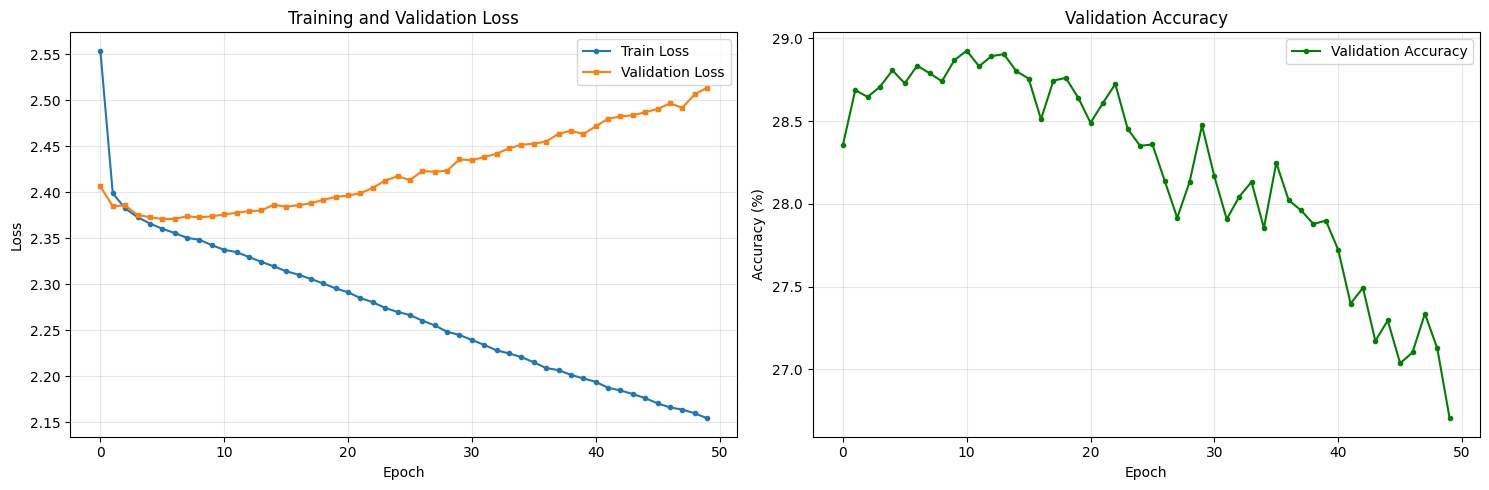

Best validation accuracy: 28.93%
Final validation accuracy: 26.70%


In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
ax1.plot(history['val_loss'], label='Validation Loss', marker='s', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['val_accuracy'], label='Validation Accuracy', marker='o', markersize=3, color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation accuracy: {max(history['val_accuracy']):.2f}%")
print(f"Final validation accuracy: {history['val_accuracy'][-1]:.2f}%")

## 8. Anomaly Detection

Use the trained DeepLog model to detect anomalies. A sequence is considered anomalous if the actual next event is not in the top-k predicted events.

In [14]:
def detect_anomaly_in_sequence(model, preprocessor, event_sequence, window_size):
    """
    Detect anomalies in a single event sequence using DeepLog.
    
    Args:
        model: Trained DeepLog model
        preprocessor: Fitted Preprocessor instance
        event_sequence: List of events
        window_size: Size of sliding window
    
    Returns:
        is_anomaly: Boolean indicating if sequence contains anomaly
        anomaly_count: Number of anomalous predictions
        total_predictions: Total number of predictions made
    """
    if len(event_sequence) <= window_size:
        return False, 0, 0
    
    # Transform the sequence
    try:
        X_test, y_test = preprocessor.transform([event_sequence], window_size=window_size)
    except:
        return False, 0, 0
    
    if len(X_test) == 0:
        return False, 0, 0
    
    # Predict anomalies using the updated method
    predictions = model.predict_sequence(X_test, y_test)
    
    # Count anomalies (predictions are boolean array: True = anomaly)
    anomaly_count = int(predictions.sum())
    total_predictions = len(predictions)
    is_anomaly = anomaly_count > 0
    
    return is_anomaly, anomaly_count, total_predictions

print("Anomaly detection function defined.")

Anomaly detection function defined.


## 9. Evaluate on Test Data

Test the model on both normal and anomalous sequences to measure detection performance.

In [15]:
# Evaluate on all sequences
print("Evaluating on test sequences...")
print(f"Using top-{num_candidates} candidates for anomaly detection\n")

y_true = []
y_pred = []
results = []

# Process all sequences (Normal + Anomaly)
for idx, row in df_seq_pd.iterrows():
    event_seq = row['e_event_drain_id']
    
    # Use the detection function
    is_anomaly, anom_count, total_preds = detect_anomaly_in_sequence(
        model, preprocessor, event_seq, window_size
    )
    
    # Only include if predictions were made (sequence length > window_size)
    if total_preds > 0:
        true_label = 1 if not row['normal'] else 0  # 1 = Anomaly, 0 = Normal
        pred_label = 1 if is_anomaly else 0
        
        y_true.append(true_label)
        y_pred.append(pred_label)
        
        results.append({
            'seq_id': row['seq_id'],
            'true_label': 'anomaly' if true_label == 1 else 'normal',
            'predicted_label': 'anomaly' if pred_label == 1 else 'normal',
            'anomaly_count': anom_count,
            'total_predictions': total_preds,
            'anomaly_rate': anom_count / total_preds
        })

print(f"\nTotal sequences evaluated: {len(y_true)}")

Evaluating on test sequences...
Using top-9 candidates for anomaly detection


Total sequences evaluated: 139


## 10. Performance Metrics

In [16]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("DEEPLOG ANOMALY DETECTION RESULTS")
print("=" * 60)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn:4d} (Normal correctly identified)")
print(f"  False Positives: {fp:4d} (Normal misclassified as anomaly)")
print(f"  False Negatives: {fn:4d} (Anomaly missed)")
print(f"  True Positives:  {tp:4d} (Anomaly correctly detected)")
print("=" * 60)

DEEPLOG ANOMALY DETECTION RESULTS

Accuracy:  0.4964
Precision: 0.4754
Recall:    0.9062
F1-Score:  0.6237

Confusion Matrix:
  True Negatives:    11 (Normal correctly identified)
  False Positives:   64 (Normal misclassified as anomaly)
  False Negatives:    6 (Anomaly missed)
  True Positives:    58 (Anomaly correctly detected)


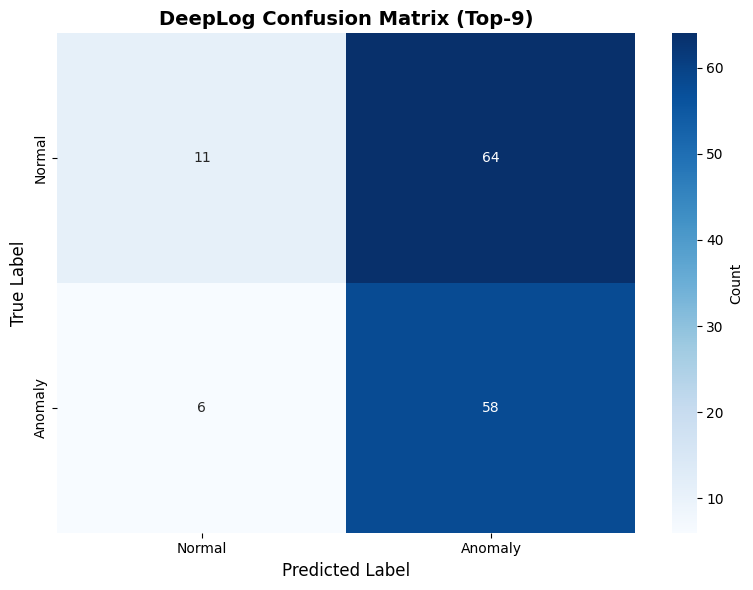

In [17]:
# Visualize confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            ax=ax, cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'DeepLog Confusion Matrix (Top-{num_candidates})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Detailed Results Analysis

In [18]:
# Create results dataframe
import pandas as pd
results_df = pd.DataFrame(results)

print("Summary Statistics:")
print("-" * 60)
print(f"Total sequences: {len(results_df)}")
print(f"\nBy true label:")
print(results_df.groupby('true_label').size())
print(f"\nBy predicted label:")
print(results_df.groupby('predicted_label').size())

print(f"\nAnomaly rate statistics:")
print(results_df.groupby('true_label')['anomaly_rate'].describe())

# Show some examples
print("\n" + "=" * 60)
print("Sample Correctly Classified Normal Sequences:")
print("=" * 60)
correct_normal = results_df[(results_df['true_label'] == 'normal') & 
                             (results_df['predicted_label'] == 'normal')]
print(correct_normal[['seq_id', 'anomaly_count', 'total_predictions', 'anomaly_rate']].head())

print("\n" + "=" * 60)
print("Sample Correctly Classified Anomalous Sequences:")
print("=" * 60)
correct_anomaly = results_df[(results_df['true_label'] == 'anomaly') & 
                              (results_df['predicted_label'] == 'anomaly')]
print(correct_anomaly[['seq_id', 'anomaly_count', 'total_predictions', 'anomaly_rate']].head())

if fp > 0:
    print("\n" + "=" * 60)
    print("Sample False Positives (Normal classified as Anomaly):")
    print("=" * 60)
    false_positives = results_df[(results_df['true_label'] == 'normal') & 
                                  (results_df['predicted_label'] == 'anomaly')]
    print(false_positives[['seq_id', 'anomaly_count', 'total_predictions', 'anomaly_rate']].head())

if fn > 0:
    print("\n" + "=" * 60)
    print("Sample False Negatives (Anomaly classified as Normal):")
    print("=" * 60)
    false_negatives = results_df[(results_df['true_label'] == 'anomaly') & 
                                  (results_df['predicted_label'] == 'normal')]
    print(false_negatives[['seq_id', 'anomaly_count', 'total_predictions', 'anomaly_rate']].head())

Summary Statistics:
------------------------------------------------------------
Total sequences: 139

By true label:
true_label
anomaly    64
normal     75
dtype: int64

By predicted label:
predicted_label
anomaly    122
normal      17
dtype: int64

Anomaly rate statistics:
            count      mean       std  min       25%       50%       75%  \
true_label                                                                 
anomaly      64.0  0.148789  0.103970  0.0  0.073336  0.139197  0.207204   
normal       75.0  0.079403  0.048083  0.0  0.040741  0.092478  0.118215   

                 max  
true_label            
anomaly     0.543771  
normal      0.146326  

Sample Correctly Classified Normal Sequences:
                                               seq_id  anomaly_count  \
5   oauth2_logs_LO2_run_1740261601__correct__light...              0   
11  oauth2_logs_LO2_run_1739570401__correct__light...              0   
21  oauth2_logs_LO2_run_1740337201__correct__light...           

## 12. Save Model and Results (Optional)

In [19]:
# Save the trained model
save_model = False  # Set to True to save

if save_model:
    model_path = "deeplog_model.pth"
    model.save(model_path)
    print(f"Model saved to {model_path}")
    
    # Save preprocessor
    import pickle
    with open("deeplog_preprocessor.pkl", "wb") as f:
        pickle.dump(preprocessor, f)
    print("Preprocessor saved to deeplog_preprocessor.pkl")
    
    # Save results
    results_df.to_csv('deeplog_results.csv', index=False)
    print("Results saved to deeplog_results.csv")
else:
    print("Model and results not saved (set save_model=True to save)")

Model and results not saved (set save_model=True to save)


## Summary

This notebook implements **DeepLog** for anomaly detection on OAuth2 logs using the DeepLog library.

### Key Steps:
1. **Data Loading**: Used LO2Loader to load OAuth2 log data with normal and anomalous sequences
2. **Preprocessing**: Applied Drain algorithm to parse raw logs into event templates
3. **DeepLog Preprocessor**: Used DeepLog's Preprocessor to create sliding windows and encode events
4. **Model Training**: Trained DeepLog LSTM model to predict next event in sequence (on normal data only)
5. **Anomaly Detection**: Flagged sequences where actual events deviate from top-k predictions

### DeepLog Library Components:
- **Preprocessor**: Handles event encoding, vocabulary creation, and sliding window generation
- **DeepLog Model**: LSTM-based model with embedding layer for sequence learning
- **Built-in Training**: Automatic train/validation split and training loop
- **Prediction API**: Simple interface for anomaly detection

### Detection Strategy:
- If the actual next event is **not** in the top-k predicted events → **Anomaly**
- Threshold controlled by `num_candidates` parameter
- Model uses LSTM layers to learn sequential patterns from normal execution

### Next Steps:
- Experiment with different hyperparameters (window_size, num_candidates, hidden_size)
- Try different error types or services individually (like Stage 2 in analysis.py)
- Compare with other methods (IsolationForest, KMeans, etc. from analysis.py)
- Fine-tune on specific error categories
- Implement ensemble approaches combining DeepLog with traditional ML methods